In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import re
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

print("Environment setup complete")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")
print(f"   Matplotlib: {plt.matplotlib.__version__}")
print(f"   Seaborn: {sns.__version__}")

Environment setup complete
   NumPy: 1.26.4
   Pandas: 3.0.1
   Matplotlib: 3.10.6
   Seaborn: 0.13.2


In [2]:
df = pd.read_csv('India_Job_Market_Salary_Trends_2026_CLEAN.csv')
df.head(5)

,job_id,job_title,company_name,location,experience_required_years,skills,salary_min_inr,salary_max_inr,employment_type,remote_option
0,1,Data Analyst,Flipkart,Noida,3,"Kubernetes, Docker, Tableau",735003,1098465,Internship,Hybrid
1,2,ML Engineer,Infosys,Kolkata,3,"Python, React, Tableau",905315,1047637,Internship,Hybrid
2,3,ML Engineer,Cognizant,Hyderabad,11,"Node.js, Machine Learning, SQL",1733025,1964890,Internship,Remote
3,4,Backend Developer,Flipkart,Chennai,4,"Python, Machine Learning, React",801572,1141406,Contract,Hybrid
4,5,Data Analyst,Cognizant,Kolkata,15,"Power BI, Docker, Azure",818144,1208834,Contract,Remote


In [3]:
print(f"Rows:{df.shape[0]:,}")
print(f"Columns:{df.shape[1]:,}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

Rows:10,000
Columns:10
   Memory: 4.22 MB


In [4]:
print(f"\n2. ACTUAL COLUMN NAMES (CRITICAL - USE THESE ONLY):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. '{col}'")

print(f"\n3. DATA TYPES:")
print(df.dtypes)


2. ACTUAL COLUMN NAMES (CRITICAL - USE THESE ONLY):
    1. 'job_id'
    2. 'job_title'
    3. 'company_name'
    4. 'location'
    5. 'experience_required_years'
    6. 'skills'
    7. 'salary_min_inr'
    8. 'salary_max_inr'
    9. 'employment_type'
   10. 'remote_option'

3. DATA TYPES:
job_id                       int64
job_title                      str
company_name                   str
location                       str
experience_required_years    int64
skills                         str
salary_min_inr               int64
salary_max_inr               int64
employment_type                str
remote_option                  str
dtype: object


In [5]:
missing = df.isnull().sum()
total_missing = missing.sum()
missing_pct = 100 * missing / len(df)

In [6]:
print(f"Total missing: {total_missing:,}")
print(f"Columns affected: {(missing > 0).sum()}/{len(df.columns)}")

Total missing: 0
Columns affected: 0/10


In [7]:
if total_missing > 0:
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing': missing.values,
        'Percent': missing_pct.values
    }).sort_values('Missing', ascending=False)

    print(f"\n   Columns with missing values:")
    display(missing_df[missing_df['Missing'] > 0])
else:
    print(f"No missing values detected!")

No missing values detected!


In [8]:
duplicates = df.duplicated().sum()
print(f"\n5. DUPLICATE ROWS: {duplicates:,} ({100*duplicates/len(df):.2f}%)")


5. DUPLICATE ROWS: 0 (0.00%)


In [9]:
print(f"\n6. STATISTICAL SUMMARY:")
display(df.describe(include='all').T)


6. STATISTICAL SUMMARY:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,10000.00,NaN,NaN,NaN,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
job_title,10000,10,Frontend Developer,1030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_name,10000,10,Accenture,1080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,10000,8,Pune,1289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_required_years,10000.00,NaN,NaN,NaN,7.49,4.60,0.00,4.00,7.00,11.00,15.00
skills,10000,1320,"Machine Learning, Tableau, AWS",21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_min_inr,10000.00,NaN,NaN,NaN,1146712.06,431001.25,400224.00,821371.25,1082927.00,1429934.50,2399534.00
salary_max_inr,10000.00,NaN,NaN,NaN,1395675.32,441501.17,517977.00,1058016.50,1337484.50,1680679.25,2790285.00
employment_type,10000,3,Contract,3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_option,10000,3,Onsite,3396,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print(f"\n7. SAMPLE DATA (First 10 Rows):")
display(df.head(10))


7. SAMPLE DATA (First 10 Rows):


,job_id,job_title,company_name,location,experience_required_years,skills,salary_min_inr,salary_max_inr,employment_type,remote_option
0,1,Data Analyst,Flipkart,Noida,3,"Kubernetes, Docker, Tableau",735003,1098465,Internship,Hybrid
1,2,ML Engineer,Infosys,Kolkata,3,"Python, React, Tableau",905315,1047637,Internship,Hybrid
2,3,ML Engineer,Cognizant,Hyderabad,11,"Node.js, Machine Learning, SQL",1733025,1964890,Internship,Remote
3,4,Backend Developer,Flipkart,Chennai,4,"Python, Machine Learning, React",801572,1141406,Contract,Hybrid
4,5,Data Analyst,Cognizant,Kolkata,15,"Power BI, Docker, Azure",818144,1208834,Contract,Remote
5,6,Cybersecurity Analyst,HCLTech,Mumbai,0,"Python, Docker, SQL",1675732,2047306,Internship,Remote
6,7,DevOps Engineer,Infosys,Kolkata,15,"React, Tableau, Docker",1685746,1860411,Contract,Remote
7,8,DevOps Engineer,Cognizant,Pune,15,"Azure, Node.js, Python",1345141,1732528,Full-time,Onsite
8,9,Business Analyst,HCLTech,Chennai,15,"Node.js, Tableau, React",980486,1354630,Internship,Hybrid
9,10,DevOps Engineer,Infosys,Kolkata,10,"Node.js, Docker, Azure",770506,1022585,Contract,Onsite


In [38]:
df_clean = df.copy()
print(f"\nStarting shape: {df_clean.shape}")
print(f"Starting missing values: {df_clean.isnull().sum().sum():,}\n")


Starting shape: (10000, 10)
Starting missing values: 0



In [12]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Found {len(numeric_cols)} numerical columns\n")

Found 4 numerical columns



In [13]:
numeric_imputation_count = 0
for col in numeric_cols:
    if df_clean[col].isnull().any():
        missing_count = df_clean[col].isnull().sum()
        missing_pct = 100 * missing_count / len(df_clean)

        if missing_pct < 50:
            fill_value = df_clean[col].median()
            df_clean[col].fillna(fill_value, inplace=True)
            print(f"{col}: Filled {missing_count} ({missing_pct:.1f}%) with median={fill_value:.2f}")
            numeric_imputation_count += 1
        else:
            print(f"⚠️ {col}: {missing_pct:.1f}% missing - will drop column")

if numeric_imputation_count == 0:
    print("No numerical columns with missing values")

print(f"\nImputed {numeric_imputation_count} numerical columns\n")

No numerical columns with missing values

Imputed 0 numerical columns



In [14]:
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Found {len(cat_cols)} categorical columns\n")

cat_imputation_count = 0
for col in cat_cols:
    if df_clean[col].isnull().any():
        missing_count = df_clean[col].isnull().sum()
        missing_pct = 100 * missing_count / len(df_clean)

        if missing_pct < 50:
            mode_values = df_clean[col].mode()
            if len(mode_values) > 0:
                fill_value = mode_values[0]
                df_clean[col].fillna(fill_value, inplace=True)
                print(f"{col}: Filled {missing_count} ({missing_pct:.1f}%) with mode='{fill_value}'")
            else:
                df_clean[col].fillna('Unknown', inplace=True)
                print(f"{col}: Filled {missing_count} ({missing_pct:.1f}%) with 'Unknown'")
            cat_imputation_count += 1
        else:
            print(f"{col}: {missing_pct:.1f}% missing - will drop column")

Found 6 categorical columns



In [15]:
if cat_imputation_count == 0:
    print("No categorical columns with missing values")
print(f"\nImputed {cat_imputation_count} categorical columns\n")

No categorical columns with missing values

Imputed 0 categorical columns



In [16]:
remaining_missing = df_clean.isnull().sum()
high_missing_cols = remaining_missing[remaining_missing / len(df_clean) > 0.5].index.tolist()

In [17]:
if len(high_missing_cols) > 0:
    print(f"Dropping {len(high_missing_cols)} columns with >50% missing:")
    for col in high_missing_cols:
        pct = 100 * remaining_missing[col] / len(df_clean)
        print(f"   - {col}: {pct:.1f}% missing")
    df_clean = df_clean.drop(columns=high_missing_cols)
    print(f"Dropped {len(high_missing_cols)} columns\n")
else:
    print("No columns with >50% missing\n")

No columns with >50% missing



In [18]:
remaining_missing_total = df_clean.isnull().sum().sum()
if remaining_missing_total > 0:
    rows_with_missing = df_clean.isnull().any(axis=1).sum()
    pct_rows = 100 * rows_with_missing / len(df_clean)

    print(f"Remaining missing values: {remaining_missing_total}")
    print(f"Rows affected: {rows_with_missing} ({pct_rows:.1f}%)")

    if pct_rows < 30:
        df_clean = df_clean.dropna()
        print(f"✅ Dropped {rows_with_missing} rows\n")
    else:
        print(f"⚠️ Would drop {pct_rows:.1f}% of data - applying forward fill instead")
        df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')
else:
    print("No remaining missing values\n")

No remaining missing values



In [19]:
final_missing = df_clean.isnull().sum().sum()
final_shape = df_clean.shape
data_retained = 100 * len(df_clean) / len(df)

print(f"Final shape: {final_shape}")
print(f"Data retained: {data_retained:.1f}%")
print(f"Missing values: {final_missing}")

Final shape: (10000, 10)
Data retained: 100.0%
Missing values: 0


In [20]:
assert final_missing == 0, f"❌ FATAL ERROR: {final_missing} missing values remain!"

In [21]:
if df_clean.duplicated().sum() > 0:
    dup_count = df_clean.duplicated().sum()
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {dup_count} duplicate rows\n")

In [22]:
job_title_col = [c for c in df_clean.columns if 'job_title' in c.lower() or 'title' in c.lower()]
if len(job_title_col) > 0:
    job_title_col = job_title_col[0]
    print(df_clean[job_title_col].value_counts().head(15))
    print()

job_title
Frontend Developer       1030
DevOps Engineer          1029
Data Analyst             1022
Data Scientist           1015
Cybersecurity Analyst    1000
Software Engineer         999
Backend Developer         991
ML Engineer               988
Business Analyst          966
Cloud Engineer            960
Name: count, dtype: int64



In [23]:
company_col = [c for c in df_clean.columns if 'company' in c.lower()]
if len(company_col) > 0:
    company_col = company_col[0]
    print(df_clean[company_col].value_counts().head(15))
    print()

company_name
Accenture        1080
Capgemini        1031
HCLTech          1015
Zoho             1014
Cognizant        1013
Tech Mahindra     996
Flipkart          988
Wipro             977
Infosys           960
TCS               926
Name: count, dtype: int64



In [24]:
location_col = [c for c in df_clean.columns if 'location' in c.lower()]
if len(location_col) > 0:
    location_col = location_col[0]
    print(df_clean[location_col].value_counts().head(10))
    print()

location
Pune         1289
Noida        1278
Hyderabad    1268
Delhi NCR    1246
Kolkata      1241
Mumbai       1237
Chennai      1232
Bangalore    1209
Name: count, dtype: int64



In [26]:
exp_col = [c for c in df_clean.columns if 'experience' in c.lower()]
if len(exp_col) > 0:
    exp_col = exp_col[0]
    print(f"Min: {df_clean[exp_col].min():.0f} years")
    print(f"Max: {df_clean[exp_col].max():.0f} years")
    print(f"Mean: {df_clean[exp_col].mean():.2f} years")
    print(f"Median: {df_clean[exp_col].median():.0f} years")
    print()

Min: 0 years
Max: 15 years
Mean: 7.49 years
Median: 7 years



In [28]:
salary_min_col = [c for c in df_clean.columns if 'salary_min' in c.lower() or 'min' in c.lower()]
salary_max_col = [c for c in df_clean.columns if 'salary_max' in c.lower() or 'max' in c.lower()]

if len(salary_min_col) > 0:
    salary_min_col = salary_min_col[0]
    print(f"\nMinimum Salary (INR):")
    print(f"   Range: ₹{df_clean[salary_min_col].min():,.0f} - ₹{df_clean[salary_min_col].max():,.0f}")
    print(f"   Mean: ₹{df_clean[salary_min_col].mean():,.0f}")
    print(f"   Median: ₹{df_clean[salary_min_col].median():,.0f}")

if len(salary_max_col) > 0:
    salary_max_col = salary_max_col[0]
    print(f"\nMaximum Salary (INR):")
    print(f"   Range: ₹{df_clean[salary_max_col].min():,.0f} - ₹{df_clean[salary_max_col].max():,.0f}")
    print(f"   Mean: ₹{df_clean[salary_max_col].mean():,.0f}")
    print(f"   Median: ₹{df_clean[salary_max_col].median():,.0f}")

if len(salary_min_col) > 0 and len(salary_max_col) > 0:
    df_clean['avg_salary'] = (df_clean[salary_min_col] + df_clean[salary_max_col]) / 2
    print(f"\nAverage Salary (INR):")
    print(f"   Mean: ₹{df_clean['avg_salary'].mean():,.0f}")
    print(f"   Median: ₹{df_clean['avg_salary'].median():,.0f}")
    print()


Minimum Salary (INR):
   Range: ₹400,224 - ₹2,399,534
   Mean: ₹1,146,712
   Median: ₹1,082,927

Maximum Salary (INR):
   Range: ₹517,977 - ₹2,790,285
   Mean: ₹1,395,675
   Median: ₹1,337,484

Average Salary (INR):
   Mean: ₹1,271,194
   Median: ₹1,210,544



In [29]:
emp_type_col = [c for c in df_clean.columns if 'employment_type' in c.lower() or 'type' in c.lower()]
if len(emp_type_col) > 0:
    emp_type_col = emp_type_col[0]
    print(df_clean[emp_type_col].value_counts())
    print()

employment_type
Contract      3372
Full-time     3355
Internship    3273
Name: count, dtype: int64



In [30]:
remote_col = [c for c in df_clean.columns if 'remote' in c.lower()]
if len(remote_col) > 0:
    remote_col = remote_col[0]
    print(df_clean[remote_col].value_counts())
    print(f"\nRemote percentage: {100 * (df_clean[remote_col] == 'Remote').sum() / len(df_clean):.1f}%")
    print()

remote_option
Onsite    3396
Remote    3358
Hybrid    3246
Name: count, dtype: int64

Remote percentage: 33.6%



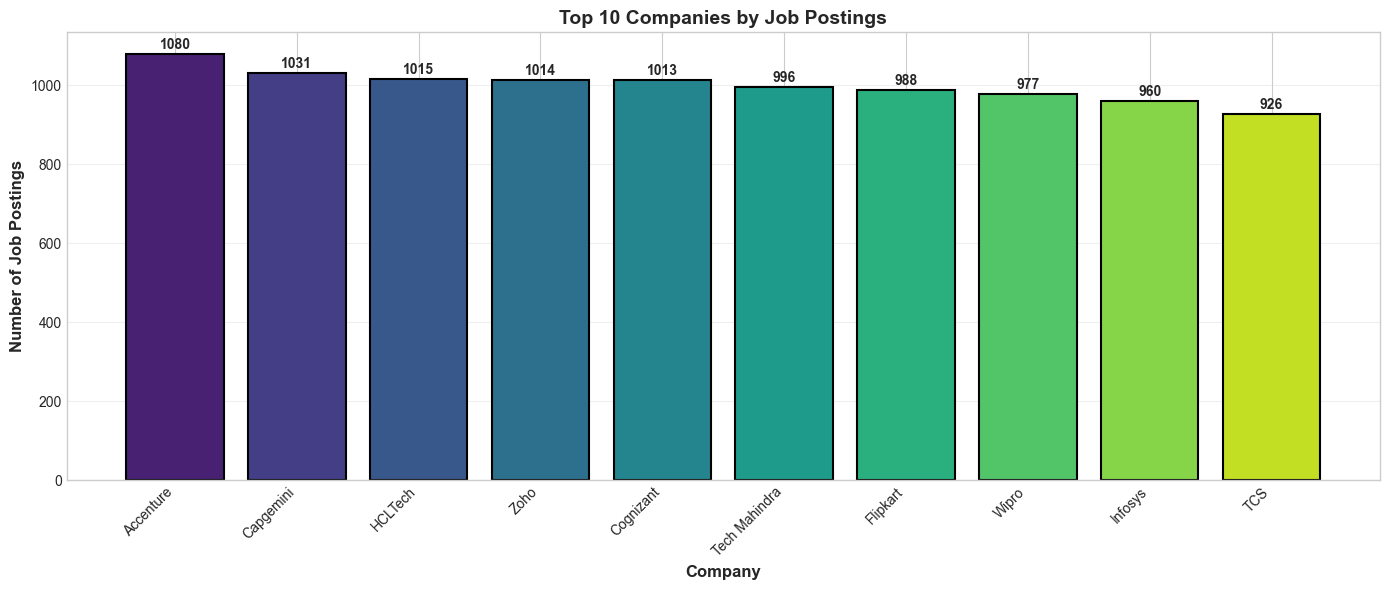

In [31]:
company_col = [c for c in df_clean.columns if 'company' in c.lower()]
if len(company_col) > 0:
    company_col = company_col[0]

    plt.figure(figsize=(14,6))
    company_counts = df_clean[company_col].value_counts().head(18)
    colors = sns.color_palette('viridis', len(company_counts))

    plt.bar(range(len(company_counts)), company_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    plt.xticks(range(len(company_counts)), company_counts.index, rotation=45, ha='right')
    plt.xlabel('Company', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Job Postings', fontsize=12, fontweight='bold')
    plt.title('Top 10 Companies by Job Postings', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    for i,v in enumerate(company_counts.values):
        plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('top_companies.png')
    plt.show()

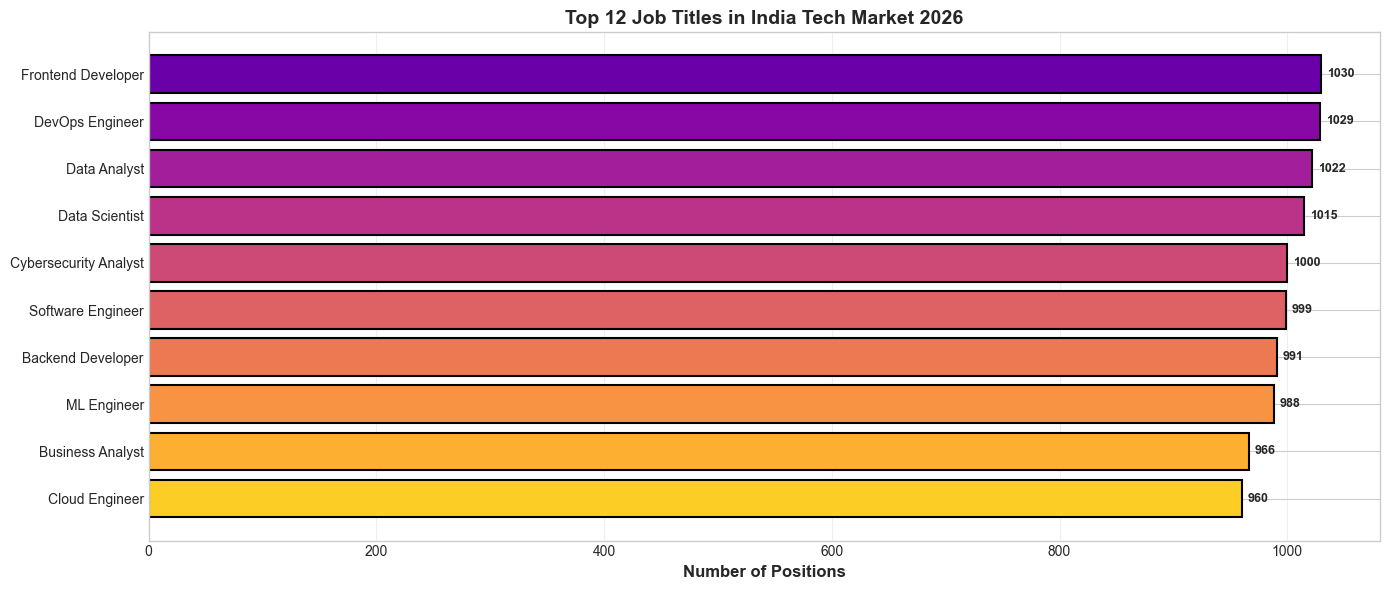

In [32]:
job_title_col = [c for c in df_clean.columns if 'job_title' in c.lower() or 'title' in c.lower()]
if len(job_title_col) > 0:
    job_title_col = job_title_col[0]

    plt.figure(figsize = (14,6))
    title_counts = df_clean[job_title_col].value_counts().head(12)
    colors_gradient = plt.cm.plasma(np.linspace(0.2, 0.9, len(title_counts)))

    plt.barh(range(len(title_counts)), title_counts.values, color=colors_gradient, edgecolor='black', linewidth=1.5)
    plt.yticks(range(len(title_counts)), title_counts.index)
    plt.xlabel('Number of Positions', fontsize=12, fontweight='bold')
    plt.title('Top 12 Job Titles in India Tech Market 2026', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.gca().invert_yaxis()

    for i,v in enumerate(title_counts.values):
        plt.text(v + 5, i, str(v), va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('top_job_titles.png')
    plt.show()

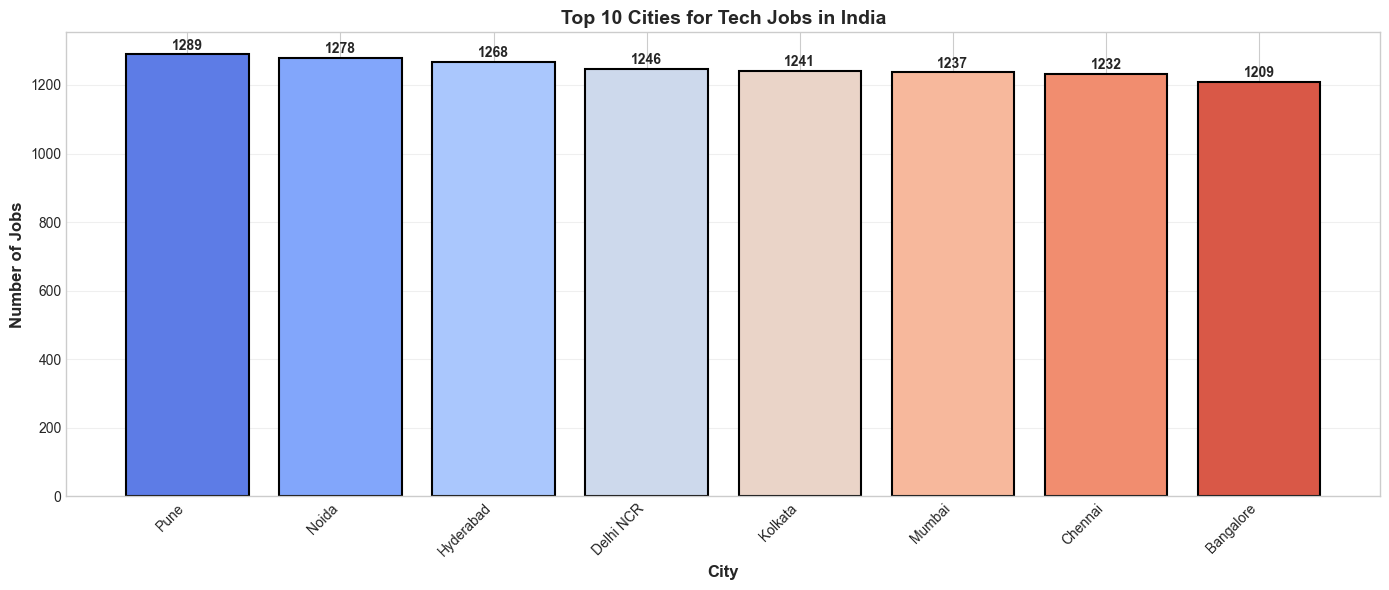

In [33]:
location_col = [c for c in df_clean.columns if 'location' in c.lower()]
if len(location_col) > 0:
    location_col = location_col[0]

    plt.figure(figsize=(14,6))
    location_counts = df_clean[location_col].value_counts().head(10)
    colors = sns.color_palette('coolwarm', len(location_counts))

    plt.bar(range(len(location_counts)), location_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    plt.xticks(range(len(location_counts)), location_counts.index, rotation=45, ha='right')
    plt.xlabel('City', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Jobs', fontsize=12, fontweight='bold')
    plt.title('Top 10 Cities for Tech Jobs in India', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    for i, v in enumerate(location_counts.values):
        plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('top_cities.png')
    plt.show()

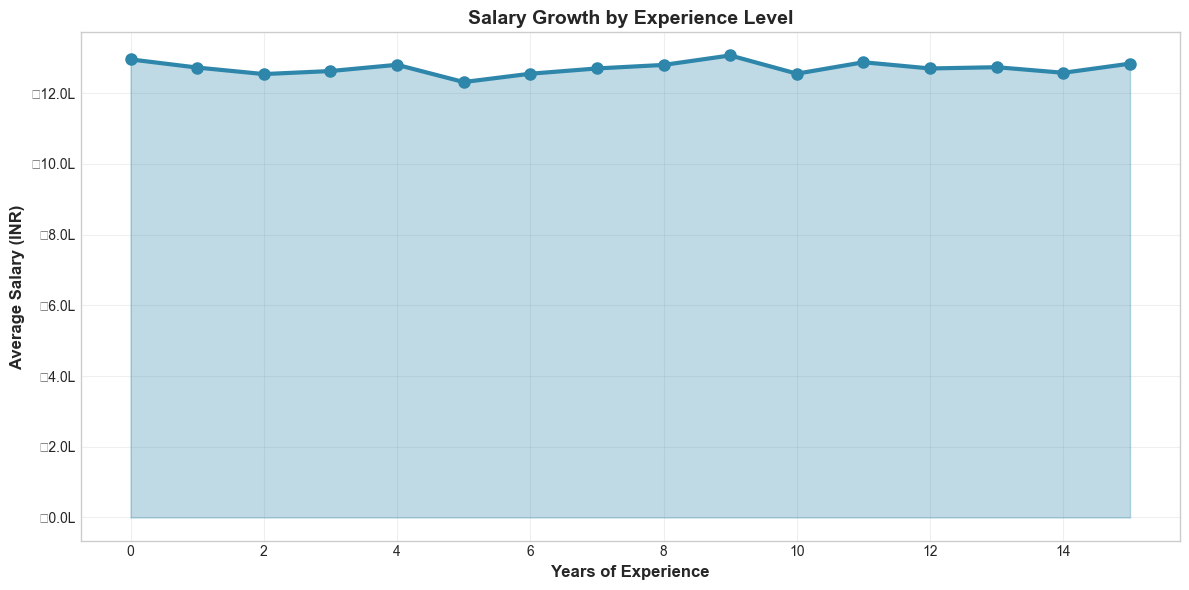

In [ ]:
exp_col = [c for c in df_clean.columns if 'experience' in c.lower()]

if len(exp_col) > 0 and 'avg_salary' in df_clean.columns:
    exp_col = exp_col[0]
    
    plt.figure(figsize=(12, 6))
    
    exp_salary = df_clean.groupby(exp_col)['avg_salary'].mean().sort_index()
    
    plt.plot(exp_salary.index, exp_salary.values, marker='o', linewidth=3, markersize=8, color='#2E86AB')
    plt.fill_between(exp_salary.index, exp_salary.values, alpha=0.3, color='#2E86AB')
    
    plt.xlabel('Years of Experience', fontsize=12, fontweight='bold')
    plt.ylabel('Average Salary (INR)', fontsize=12, fontweight='bold')
    plt.title('Salary Growth by Experience Level', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/100000:.1f}L'))
    
    plt.tight_layout()
    plt.savefig('salary_by_experience.png')
    plt.show()

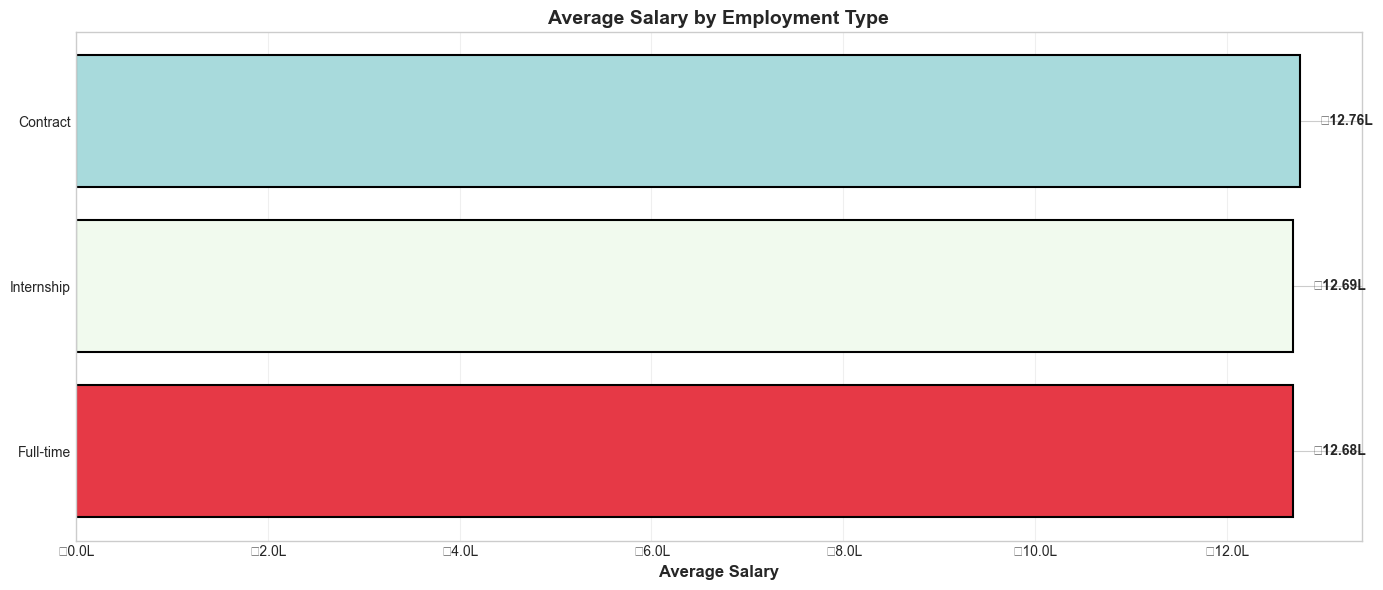

In [37]:
emp_type_col = [c for c in df_clean.columns if 'employment_type' in c.lower() or 'type' in c.lower()]
if len(emp_type_col) > 0 and 'avg_salary' in df_clean.columns:
    emp_type_col = emp_type_col[0]

    plt.figure(figsize = (14,6))

    emp_salary = df_clean.groupby(emp_type_col)['avg_salary'].mean().sort_values(ascending=True)
    colors = ['#E63946', '#F1FAEE', '#A8DADC']

    plt.barh(range(len(emp_salary)), emp_salary.values, color=colors[:len(emp_salary)], edgecolor='black', linewidth=1.5)
    plt.yticks(range(len(emp_salary)), emp_salary.index)
    plt.xlabel('Average Salary', fontsize = 12, fontweight = 'bold')
    plt.title('Average Salary by Employment Type', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/100000:.1f}L'))

    for i,v in enumerate(emp_salary.values):
        plt.text(v + 20000, i, f'₹{v/100000:.2f}L', va='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('salary_by_employment_type.png')
    plt.show()


SKILLS ANALYSIS

Total unique skills: 12

Top 20 Most Demanded Skills:
--------------------------------------------------
 1. SQL                 : 2608 jobs ( 26.1%)
 2. AWS                 : 2554 jobs ( 25.5%)
 3. Python              : 2545 jobs ( 25.4%)
 4. Machine Learning    : 2526 jobs ( 25.3%)
 5. Power BI            : 2519 jobs ( 25.2%)
 6. Tableau             : 2518 jobs ( 25.2%)
 7. Node.js             : 2497 jobs ( 25.0%)
 8. Azure               : 2474 jobs ( 24.7%)
 9. Docker              : 2457 jobs ( 24.6%)
10. React               : 2449 jobs ( 24.5%)
11. Java                : 2427 jobs ( 24.3%)
12. Kubernetes          : 2426 jobs ( 24.3%)


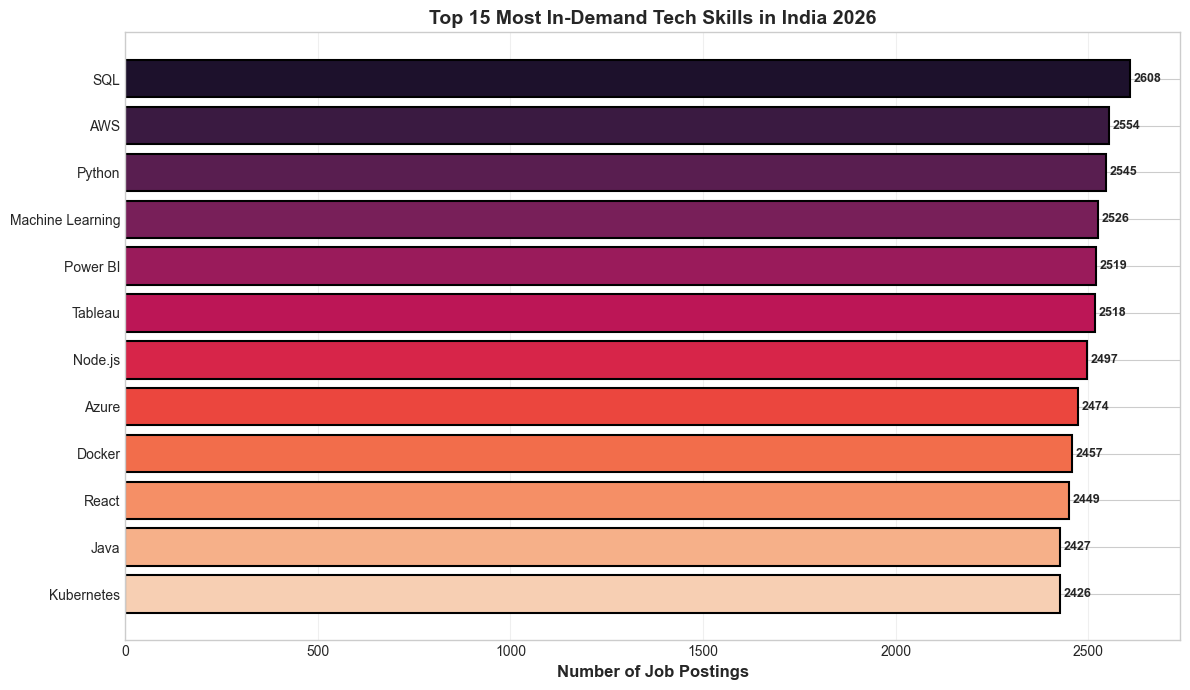

In [49]:
skills_col = [c for c in df_clean.columns if 'skills' in c.lower()]

if len(skills_col) > 0:
    skills_col = skills_col[0]
    
    print("\nSKILLS ANALYSIS")
    print("="*60)
    
    all_skills = []
    for skills_str in df_clean[skills_col].dropna():
        skills_list = [s.strip() for s in str(skills_str).split(',')]
        all_skills.extend(skills_list)
    
    from collections import Counter
    skill_counts = Counter(all_skills)
    
    print(f"\nTotal unique skills: {len(skill_counts)}")
    print(f"\nTop 20 Most Demanded Skills:")
    print("-" * 50)
    
    for i, (skill, count) in enumerate(skill_counts.most_common(20), 1):
        pct = 100 * count / len(df_clean)
        print(f"{i:2d}. {skill:20s}: {count:4d} jobs ({pct:5.1f}%)")
    
    top_skills = dict(skill_counts.most_common(15))
    
    plt.figure(figsize=(12, 7))
    colors = sns.color_palette('rocket', len(top_skills))
    
    plt.barh(range(len(top_skills)), list(top_skills.values()), color=colors, edgecolor='black', linewidth=1.5)
    plt.yticks(range(len(top_skills)), list(top_skills.keys()))
    plt.xlabel('Number of Job Postings', fontsize=12, fontweight='bold')
    plt.title('Top 15 Most In-Demand Tech Skills in India 2026', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.gca().invert_yaxis()
    
    for i, v in enumerate(list(top_skills.values())):
        plt.text(v + 10, i, str(v), va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [50]:
df_feat = df_clean.copy()

In [51]:
salary_min_col = [c for c in df_feat.columns if 'salary_min' in c.lower()]
salary_max_col = [c for c in df_feat.columns if 'salary_max' in c.lower()]
if len(salary_min_col) > 0 and len(salary_max_col) > 0:
    salary_min_col = salary_min_col[0]
    salary_max_col = salary_max_col[0]

    if 'avg_salary' not in df_feat.columns:
        df_feat['avg_salary'] = (df_feat[salary_min_col] + df_feat[salary_max_col]) / 2

    df_feat['salary_range'] = df_feat[salary_max_col] - df_feat[salary_min_col]
    print("Created: salary_range")

    exp_col = [c for c in df_feat.columns if 'experience' in c.lower()]
    if len(exp_col) > 0:
        exp_col = exp_col[0]
        df_feat['salary_per_exp_year'] = df_feat['avg_salary'] / (df_feat[exp_col] + 1)
        print("Created: salary_per_exp_year")

Created: salary_range
Created: salary_per_exp_year


In [52]:
skills_col = [c for c in df_feat.columns if 'skills' in c.lower()]
if len(skills_col) > 0:
    skills_col = skills_col[0]
    df_feat['num_skills_required'] = df_feat[skills_col].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
    print("Created: num_skills_required")

Created: num_skills_required


In [53]:
high_value_skills = ['AWS', 'Azure', 'Kubernetes', 'Docker', 'Machine Learning', 'Python', 'Java']
for skill in high_value_skills:
    col_name = f'has_{skill.lower().replace(" ", "_")}'
    df_feat[col_name] = df_feat[skills_col].apply(lambda x: 1 if skill in str(x) else 0)
    print(f"Created: {col_name}")

Created: has_aws
Created: has_azure
Created: has_kubernetes
Created: has_docker
Created: has_machine_learning
Created: has_python
Created: has_java


In [54]:
exp_col = [c for c in df_feat.columns if 'experience' in c.lower()]
if len(exp_col) > 0:
    exp_col = exp_col[0]
    df_feat['exp_category'] = pd.cut(df_feat[exp_col], 
                                       bins=[-1, 2, 5, 10, 20], 
                                       labels=['Entry', 'Mid', 'Senior', 'Expert'])
    print("Created: exp_category")

Created: exp_category


In [55]:
location_col = [c for c in df_feat.columns if 'location' in c.lower()]
if len(location_col) > 0:
    location_col = location_col[0]
    tier1_cities = ['Bangalore', 'Mumbai', 'Delhi NCR', 'Pune', 'Hyderabad', 'Chennai']
    df_feat['is_tier1_city'] = df_feat[location_col].apply(lambda x: 1 if x in tier1_cities else 0)
    print("Created: is_tier1_city")

Created: is_tier1_city


In [56]:
remote_col = [c for c in df_feat.columns if 'remote' in c.lower()]
if len(remote_col) > 0:
    remote_col = remote_col[0]
    df_feat['is_remote'] = df_feat[remote_col].apply(lambda x: 1 if x == 'Remote' else 0)
    df_feat['is_hybrid'] = df_feat[remote_col].apply(lambda x: 1 if x == 'Hybrid' else 0)
    print("Created: is_remote, is_hybrid")

Created: is_remote, is_hybrid


In [57]:
emp_type_col = [c for c in df_feat.columns if 'employment_type' in c.lower()]
if len(emp_type_col) > 0:
    emp_type_col = emp_type_col[0]
    df_feat['is_fulltime'] = df_feat[emp_type_col].apply(lambda x: 1 if x == 'Full-time' else 0)
    print("Created: is_fulltime")

Created: is_fulltime


In [58]:
job_title_col = [c for c in df_feat.columns if 'job_title' in c.lower()]
if len(job_title_col) > 0:
    job_title_col = job_title_col[0]
    
    def categorize_job(title):
        title = str(title).lower()
        if 'data scientist' in title or 'ml engineer' in title:
            return 'Data_Science_ML'
        elif 'data analyst' in title:
            return 'Data_Analytics'
        elif 'backend' in title or 'frontend' in title or 'software' in title:
            return 'Software_Development'
        elif 'devops' in title or 'cloud' in title:
            return 'DevOps_Cloud'
        elif 'cybersecurity' in title:
            return 'Cybersecurity'
        elif 'business analyst' in title:
            return 'Business_Analytics'
        else:
            return 'Other'
    
    df_feat['job_category'] = df_feat[job_title_col].apply(categorize_job)
    print("Created: job_category")

print(f"\nFeature engineering complete. Shape: {df_feat.shape}")

Created: job_category

Feature engineering complete. Shape: (10000, 27)


In [59]:
if 'avg_salary' in df_feat.columns:
    target_col = 'avg_salary'
elif 'salary_min_inr' in df_feat.columns:
    target_col = 'salary_min_inr'
else:
    salary_cols = [c for c in df_feat.columns if 'salary' in c.lower()]
    target_col = salary_cols[0] if len(salary_cols) > 0 else df_feat.select_dtypes(include=[np.number]).columns[-1]
print(f"Target Variable: {target_col}")

Target Variable: avg_salary


In [60]:
y = df_feat[target_col].copy()
X = df_feat.drop(columns = [target_col]).copy()

In [66]:
salary_leak_cols = [c for c in X.columns if 'salary' in c.lower()]
if len(salary_leak_cols) > 0:
    print(f"\nRemoving {len(salary_leak_cols)} salary columns to prevent data leakage:")
    for col in salary_leak_cols:
        print(f"   - {col}")
    X = X.drop(columns=salary_leak_cols)

id_cols = [c for c in X.columns if 'id' in c.lower()]
if len(id_cols) > 0:
    print(f"\nRemoving {len(id_cols)} ID columns:")
    for col in id_cols:
        print(f"   - {col}")
    X = X.drop(columns=id_cols)

print("\n Encoding Categorical Variables")

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Found {len(cat_cols)} categorical columns\n")

for col in cat_cols:
    unique_vals = X[col].nunique()
    print(f"   {col}: {unique_vals} unique values", end=" ")
    
    if unique_vals <= 10:
        dummies = pd.get_dummies(X[col], prefix=col, drop_first=True, dtype=int)
        X = pd.concat([X.drop(columns=[col]), dummies], axis=1)
        print(f"→ One-hot encoded ({len(dummies.columns)} new cols)")
    else:
        X[col] = X[col].astype('category').cat.codes
        print(f"→ Label encoded")

print(f"\n Final feature matrix: {X.shape}")
print(f"   Target vector: {y.shape}")


 Encoding Categorical Variables
Found 0 categorical columns


 Final feature matrix: (10000, 48)
   Target vector: (10000,)


In [67]:
assert X.isnull().sum().sum() == 0, "Missing values detected in features!"
assert y.isnull().sum() == 0, "Missing values detected in target!"

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples ({100*len(X_train)/len(X):.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({100*len(X_test)/len(X):.1f}%)")
print(f"Features: {X_train.shape[1]}")

print(f"\nTarget Statistics:")
print(f"  Train mean: ₹{y_train.mean():,.0f}")
print(f"  Test mean: ₹{y_test.mean():,.0f}")
print(f"  Train std: ₹{y_train.std():,.0f}")
print(f"  Test std: ₹{y_test.std():,.0f}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling complete")

Training set: 8,000 samples (80.0%)
Test set: 2,000 samples (20.0%)
Features: 48

Target Statistics:
  Train mean: ₹1,271,231
  Test mean: ₹1,271,045
  Train std: ₹434,077
  Test std: ₹434,338

Feature scaling complete


In [71]:
models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if name in ['Ridge Regression', 'Lasso Regression', 'ElasticNet']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    results.append({
        'Model': name,
        'R² Score': r2,
        'RMSE (INR)': rmse,
        'MAE (INR)': mae,
        'MAPE (%)': mape
    })
    
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: ₹{rmse:,.0f}")
    print(f"  MAE: ₹{mae:,.0f}")
    print(f"  MAPE: {mape:.2f}%")

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)


print("MODEL COMPARISON SUMMARY")
display(results_df)

best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R² Score']
best_rmse = results_df.iloc[0]['RMSE (INR)']

print(f"\nBEST MODEL: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   RMSE: ₹{best_rmse:,.0f}")
print("\n" + "="*80 + "\n")


Training Ridge Regression...
  R² Score: 0.4496
  RMSE: ₹322,146
  MAE: ₹269,765
  MAPE: 23.24%

Training Lasso Regression...
  R² Score: 0.4496
  RMSE: ₹322,145
  MAE: ₹269,765
  MAPE: 23.24%

Training ElasticNet...
  R² Score: 0.4491
  RMSE: ₹322,288
  MAE: ₹269,715
  MAPE: 23.26%

Training Random Forest...
  R² Score: 0.4242
  RMSE: ₹329,487
  MAE: ₹272,632
  MAPE: 23.44%

Training Gradient Boosting...
  R² Score: 0.4295
  RMSE: ₹327,966
  MAE: ₹271,879
  MAPE: 23.40%

Training XGBoost...
  R² Score: 0.4194
  RMSE: ₹330,862
  MAE: ₹273,425
  MAPE: 23.44%

Training LightGBM...
  R² Score: 0.4331
  RMSE: ₹326,930
  MAE: ₹271,443
  MAPE: 23.36%
MODEL COMPARISON SUMMARY


,Model,R² Score,RMSE (INR),MAE (INR),MAPE (%)
1,Lasso Regression,0.45,322145.48,269764.76,23.24
0,Ridge Regression,0.45,322145.64,269764.53,23.24
2,ElasticNet,0.45,322287.59,269714.73,23.26
6,LightGBM,0.43,326929.65,271443.41,23.36
4,Gradient Boosting,0.43,327965.59,271879.09,23.40
3,Random Forest,0.42,329487.20,272632.17,23.44
5,XGBoost,0.42,330861.87,273425.42,23.44



BEST MODEL: Lasso Regression
   R² Score: 0.4496
   RMSE: ₹322,145




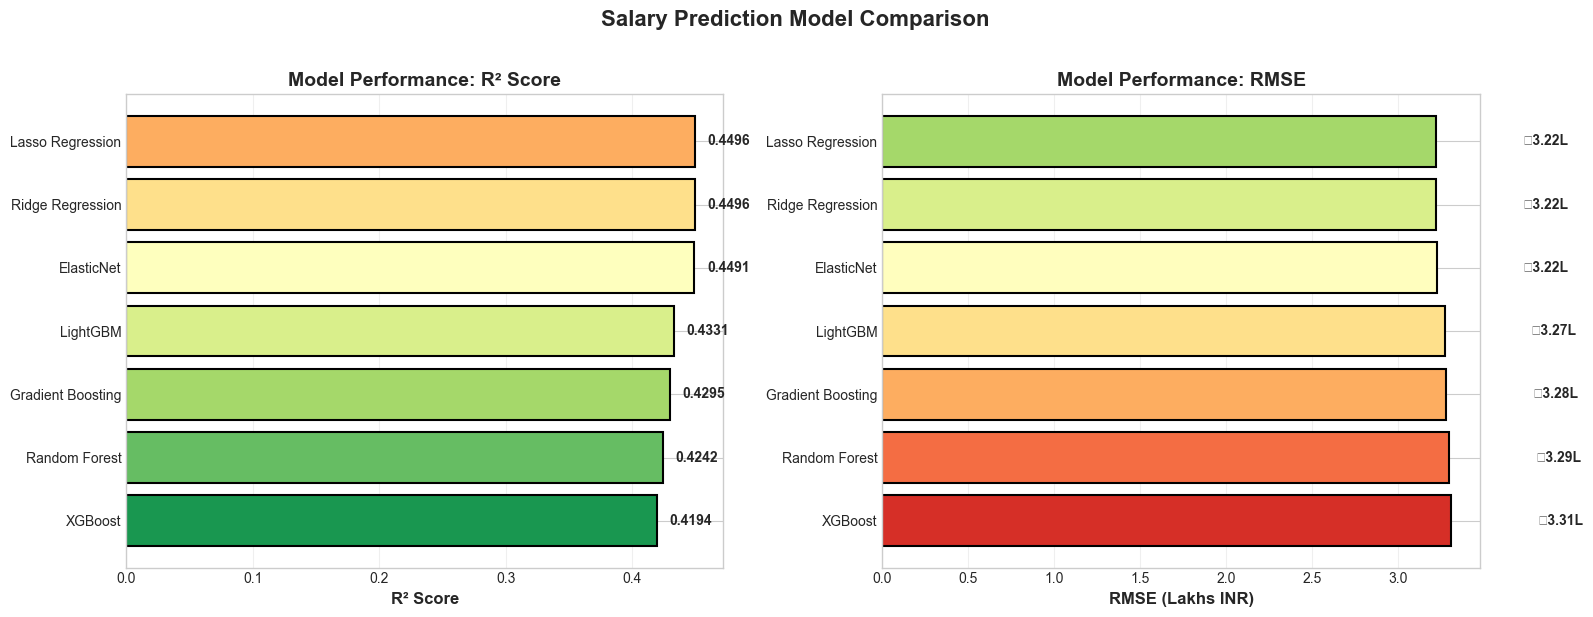

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))
axes[0].barh(range(len(results_df)), results_df['R² Score'], color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels(results_df['Model'])
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance: R² Score', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

for i, v in enumerate(results_df['R² Score']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

colors_rmse = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(results_df)))
axes[1].barh(range(len(results_df)), results_df['RMSE (INR)']/100000, color=colors_rmse, edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(results_df)))
axes[1].set_yticklabels(results_df['Model'])
axes[1].set_xlabel('RMSE (Lakhs INR)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Performance: RMSE', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

for i, v in enumerate(results_df['RMSE (INR)']):
    axes[1].text(v/100000 + 0.5, i, f'₹{v/100000:.2f}L', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Salary Prediction Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Different-types-of-models.png')
plt.show()


FEATURE IMPORTANCE ANALYSIS (LightGBM)

Top 20 Most Important Features:
------------------------------------------------------------


,Feature,Importance
1,skills,869
0,experience_required_years,431
11,is_remote,98
38,employment_type_Internship,84
8,has_python,78
45,job_category_Data_Science_ML,68
12,is_fulltime,66
39,remote_option_Onsite,65
5,has_kubernetes,64
25,company_name_HCLTech,53


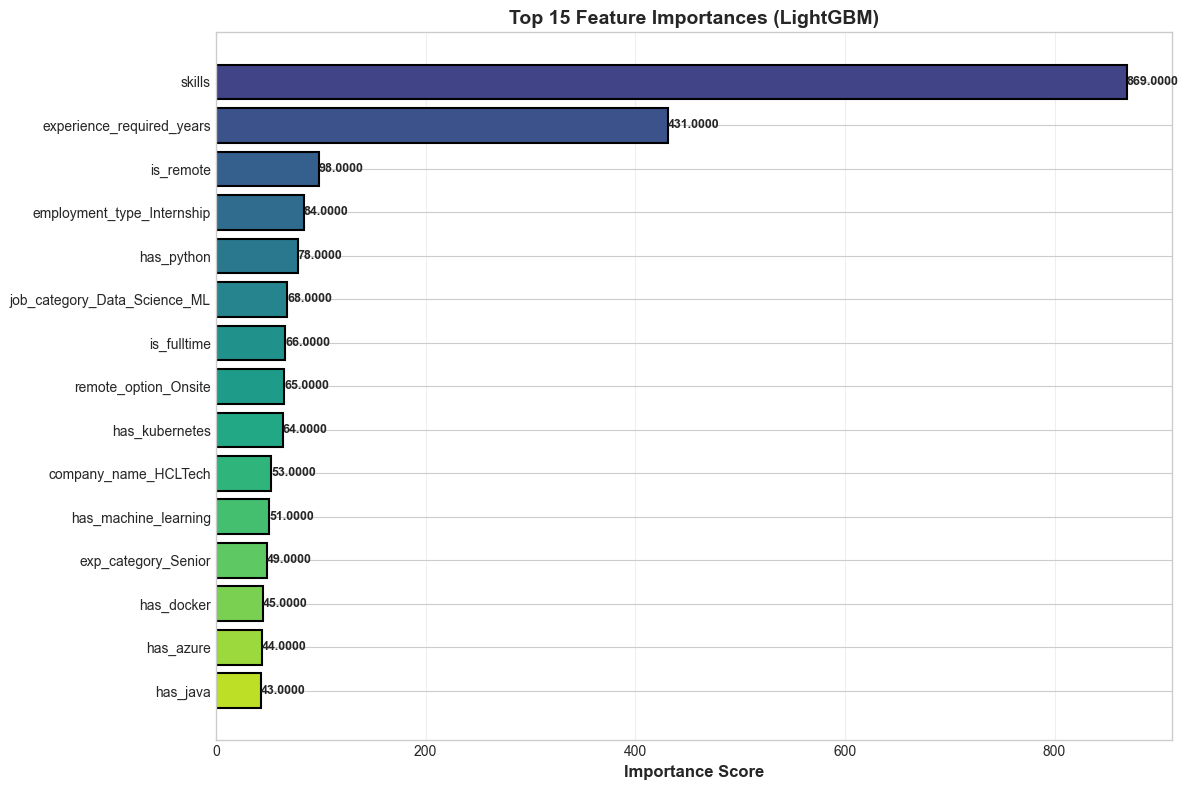

In [73]:
best_tree_model = None
best_tree_name = None

for name in ['LightGBM', 'XGBoost', 'Gradient Boosting', 'Random Forest']:
    if name in models:
        best_tree_model = models[name]
        best_tree_name = name
        break

if best_tree_model is not None:
    print(f"\nFEATURE IMPORTANCE ANALYSIS ({best_tree_name})")
    
    
    importances = best_tree_model.feature_importances_
    feature_names = X.columns
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 20 Most Important Features:")
    print("-" * 60)
    display(importance_df.head(20))
    
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_features)))
    
    plt.barh(range(len(top_features)), top_features['Importance'], color=colors, edgecolor='black', linewidth=1.5)
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Feature Importances ({best_tree_name})', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.gca().invert_yaxis()
    
    for i, v in enumerate(top_features['Importance']):
        plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()

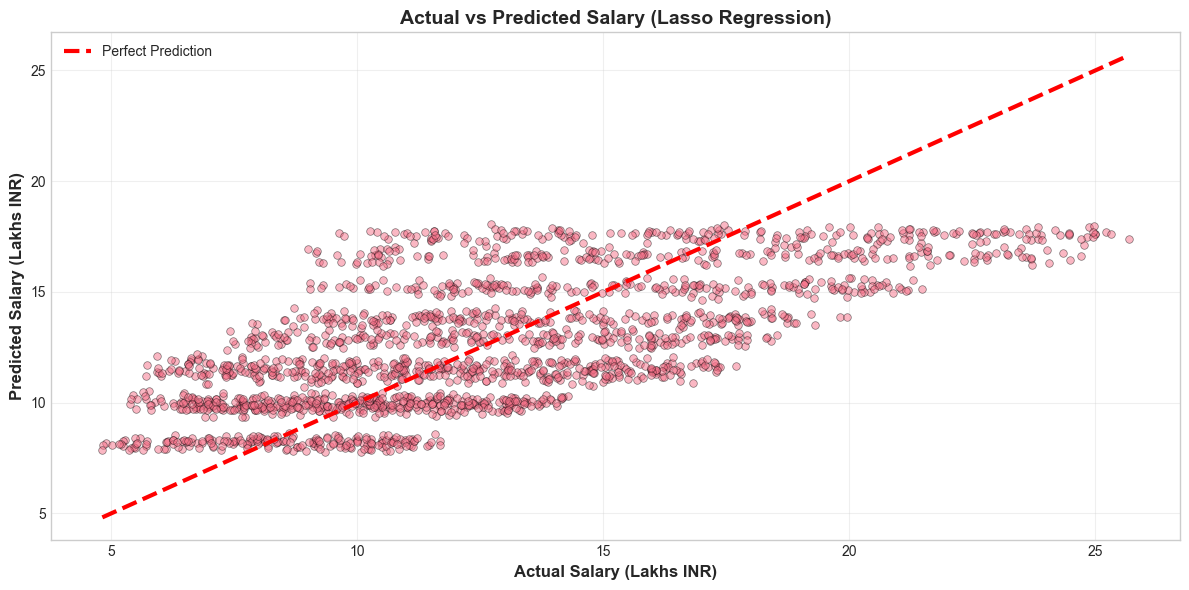

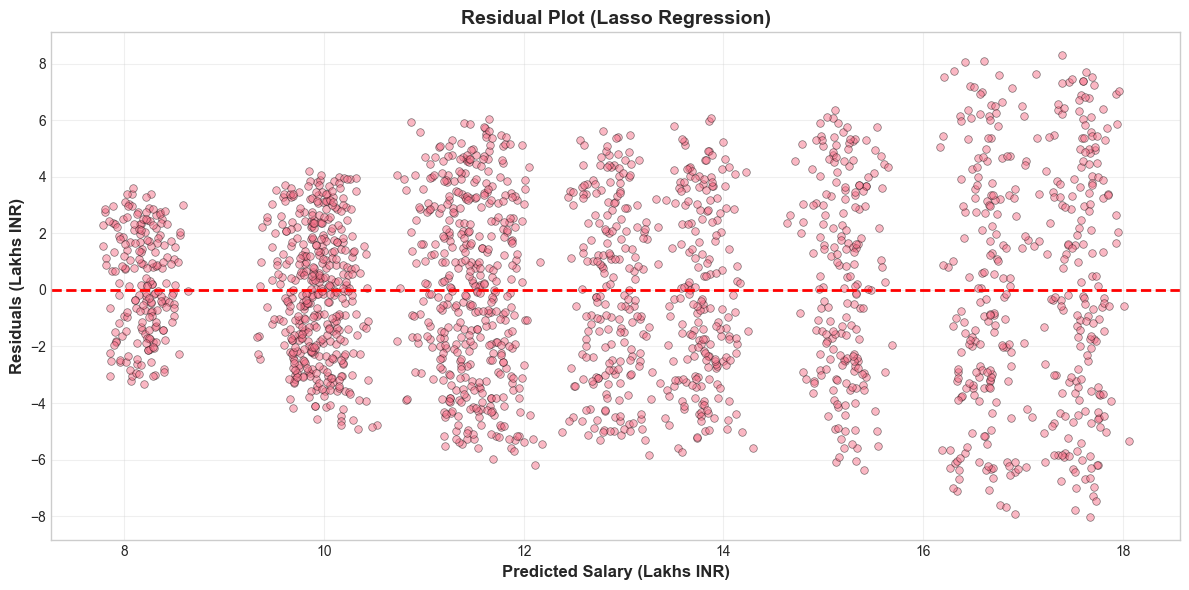

In [74]:
best_model = models[best_model_name]

if best_model_name in ['Ridge Regression', 'Lasso Regression', 'ElasticNet']:
    y_pred_final = best_model.predict(X_test_scaled)
else:
    y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(12, 6))

plt.scatter(y_test/100000, y_pred_final/100000, alpha=0.5, s=30, edgecolor='black', linewidth=0.5)
plt.plot([y_test.min()/100000, y_test.max()/100000], 
         [y_test.min()/100000, y_test.max()/100000], 
         'r--', linewidth=3, label='Perfect Prediction')

plt.xlabel('Actual Salary (Lakhs INR)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Salary (Lakhs INR)', fontsize=12, fontweight='bold')
plt.title(f'Actual vs Predicted Salary ({best_model_name})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Actual_vs_predicted.png')
plt.show()

residuals = y_test - y_pred_final

plt.figure(figsize=(12, 6))
plt.scatter(y_pred_final/100000, residuals/100000, alpha=0.5, s=30, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Salary (Lakhs INR)', fontsize=12, fontweight='bold')
plt.ylabel('Residuals (Lakhs INR)', fontsize=12, fontweight='bold')
plt.title(f'Residual Plot ({best_model_name})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residual.png')
plt.show()